In [ ]:
import pandas as pd

# Carga como tabla estructurada
df = pd.read_csv("/content/pacientes_biomedicina.csv")

# Vista rápida
print("Filas:", df.shape[0], "Columnas:", df.shape[1])
df.head()

#Se usa pd.read_csv porque el archivo es una tabla de pacientes con columnas y filas, igual que en los ejemplos de hígado e Iris donde se cargan datasets tabulares con pandas.

#Pandas ofrece directamente métodos de inspección (head, info, describe) y facilita todo el análisis descriptivo posterior.



Filas: 101000 Columnas: 26


,id,fecha_ingreso,edad,sexo,fumador,alcohol,imc,ps,pdia,fc,...,egfr,diabetes,hipertension,epoc,enf_renal,metformina,estatinas,antihipertensivos,estancia_dias,reingreso_30d
0,1,2024-10-05,35,F,No,Ninguno,19.8,137.910324,75.592721,70.339345,...,68.825928,1,0,0,0,1,0,0,4,0
1,2,2024-06-24,72,F,No,Ninguno,35.0,158.833950,96.239109,68.584455,...,69.108865,0,1,0,0,0,1,0,3,0
2,3,2024-12-20,60,F,No,Ninguno,36.2,152.181182,85.743313,54.406740,...,78.453453,1,1,0,0,0,0,1,1,1
3,4,2024-06-13,27,F,No,Moderado,26.8,137.492298,85.225100,65.753860,...,75.319606,0,0,0,0,0,0,0,7,1
4,5,2024-11-07,44,M,No,Ninguno,31.5,133.643569,74.415364,84.392010,...,81.264671,0,0,0,0,0,0,0,3,0


In [ ]:
# Inspección básica
print("Info general del DataFrame:")
print(df.info())

# Resumen numérico explícito
n_filas = df.shape[0]
n_columnas = df.shape[1]
tipos = df.dtypes

print(f"\nNúmero de entradas (filas) = {n_filas}")
print(f"Número de columnas = {n_columnas}")
print("\nTipos de datos por columna:")
print(tipos)

Info general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 101000 non-null  int64  
 1   fecha_ingreso      101000 non-null  object 
 2   edad               101000 non-null  int64  
 3   sexo               101000 non-null  object 
 4   fumador            101000 non-null  object 
 5   alcohol            101000 non-null  object 
 6   imc                99041 non-null   float64
 7   ps                 101000 non-null  float64
 8   pdia               101000 non-null  float64
 9   fc                 101000 non-null  float64
 10  temp               101000 non-null  float64
 11  glucosa            97970 non-null   float64
 12  hbA1c              96045 non-null   float64
 13  colesterol_total   101000 non-null  float64
 14  trigliceridos      101000 non-null  float64
 15  creatinina         9895

In [ ]:
# Estadísticos básicos de numéricas
print("\nDescripción básica de variables numéricas:")
print(df.describe())  # count, mean, std, min, Q1, mediana, Q3, max [file:5]

# Medidas de dispersión adicionales
print("\nRango (max - min) de cada variable numérica:")
print((df.max(numeric_only=True) - df.min(numeric_only=True)))

print("\nCoeficiente de variación (std / media):")
print((df.std(numeric_only=True) / df.mean(numeric_only=True)))

# Estadísticos por variable categórica (si tienes categóricas)
cat_cols = df.select_dtypes(exclude="number").columns
for col in cat_cols:
    print(f"\nFrecuencias de la variable categórica '{col}':")
    print(df[col].value_counts())
    print("\nFrecuencias relativas:")
    print(df[col].value_counts(normalize=True).round(3))


Descripción básica de variables numéricas:
                  id           edad           imc             ps  \
count  101000.000000  101000.000000  99041.000000  101000.000000   
mean    50003.326812      54.583970     27.006261     130.059637   
std     28865.352298      17.466943      4.991336      19.817779   
min         1.000000      18.000000      3.300000      80.000000   
25%     24995.750000      42.000000     23.600000     116.606156   
50%     50014.500000      55.000000     27.000000     130.002519   
75%     74995.250000      67.000000     30.400000     143.486724   
max    100000.000000      95.000000     48.500000     213.044400   

                pdia             fc           temp       glucosa  \
count  101000.000000  101000.000000  101000.000000  97970.000000   
mean       80.094416      78.027309      36.796592    103.015898   
std        11.937738      11.961085       0.598392     27.933066   
min        50.000000      40.000000      34.500000     50.000000   
25%

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

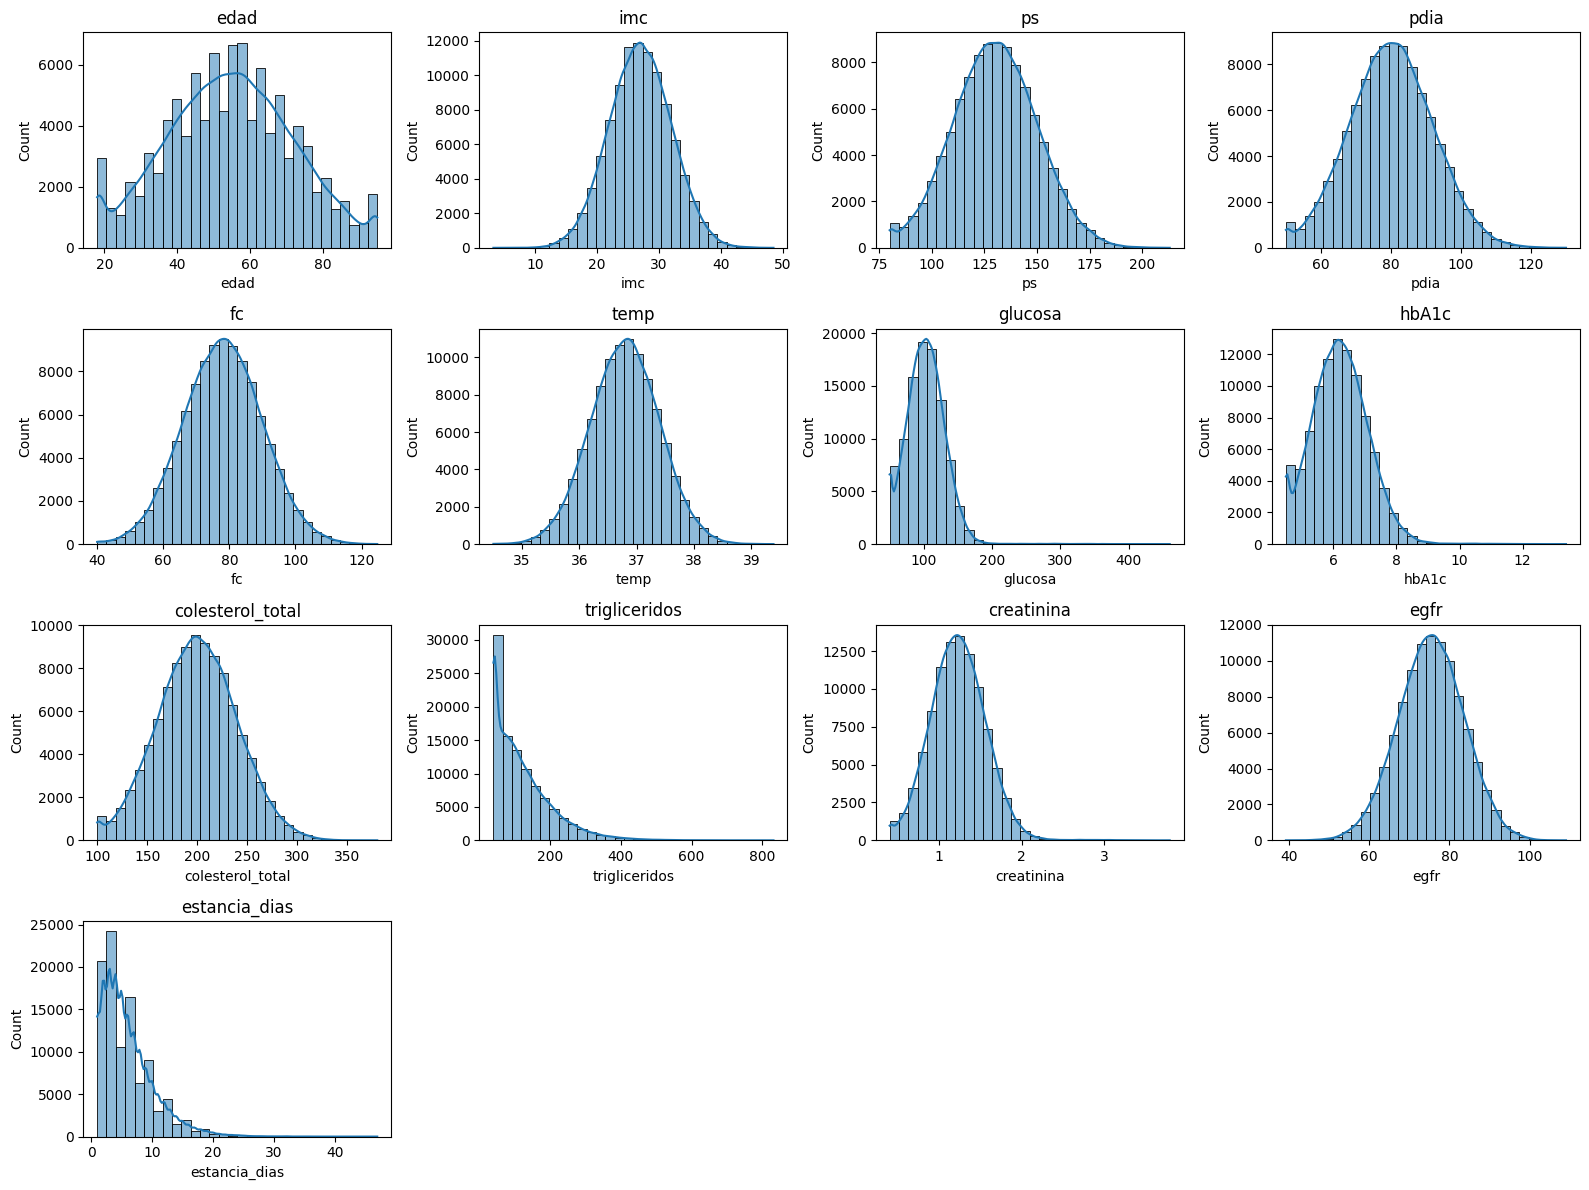

In [ ]:
#histogramas de variables numéricas
numeric_cols = [
    'edad','imc','ps','pdia','fc','temp','glucosa','hbA1c',
    'colesterol_total','trigliceridos','creatinina','egfr','estancia_dias'
]

df_numeric = df[numeric_cols]

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_numeric[col].dropna(), kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

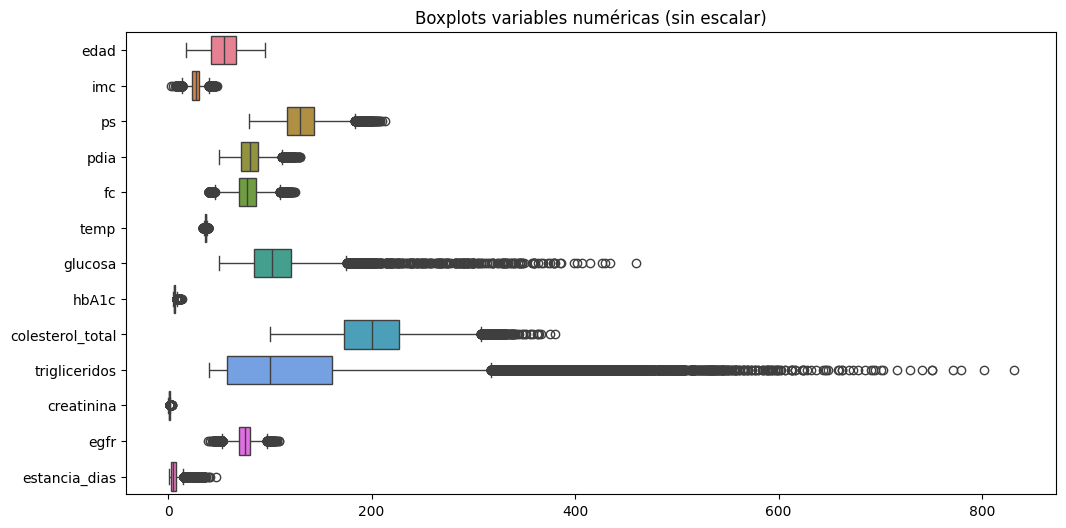

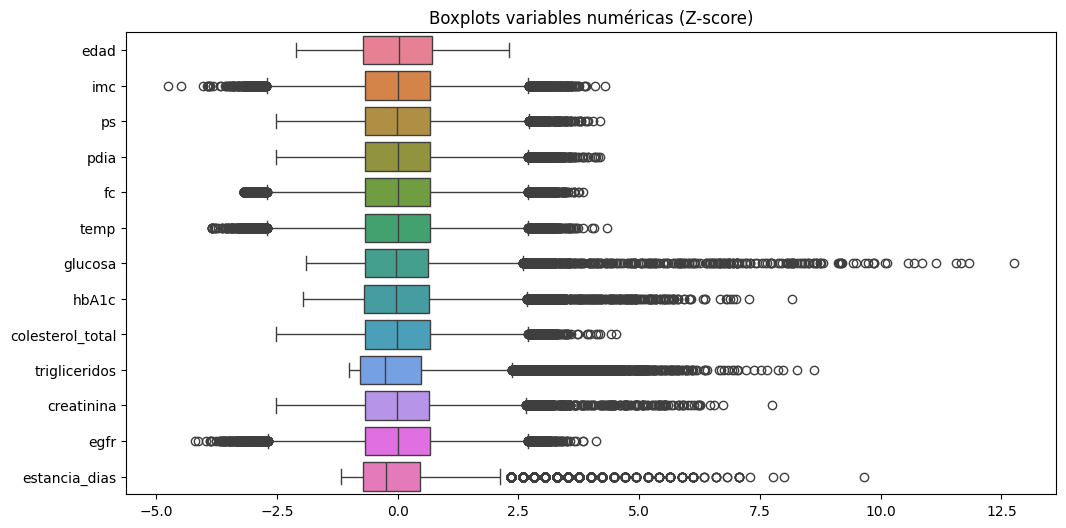

In [ ]:
#boxplot sin y con estandarización
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_numeric, orient='h')
plt.title('Boxplots variables numéricas (sin escalar)')
plt.show()

# Estandarizar
scaler = StandardScaler()
scaled = scaler.fit_transform(df_numeric.dropna())
df_scaled = pd.DataFrame(scaled, columns=df_numeric.columns)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, orient='h')
plt.title('Boxplots variables numéricas (Z-score)')
plt.show()

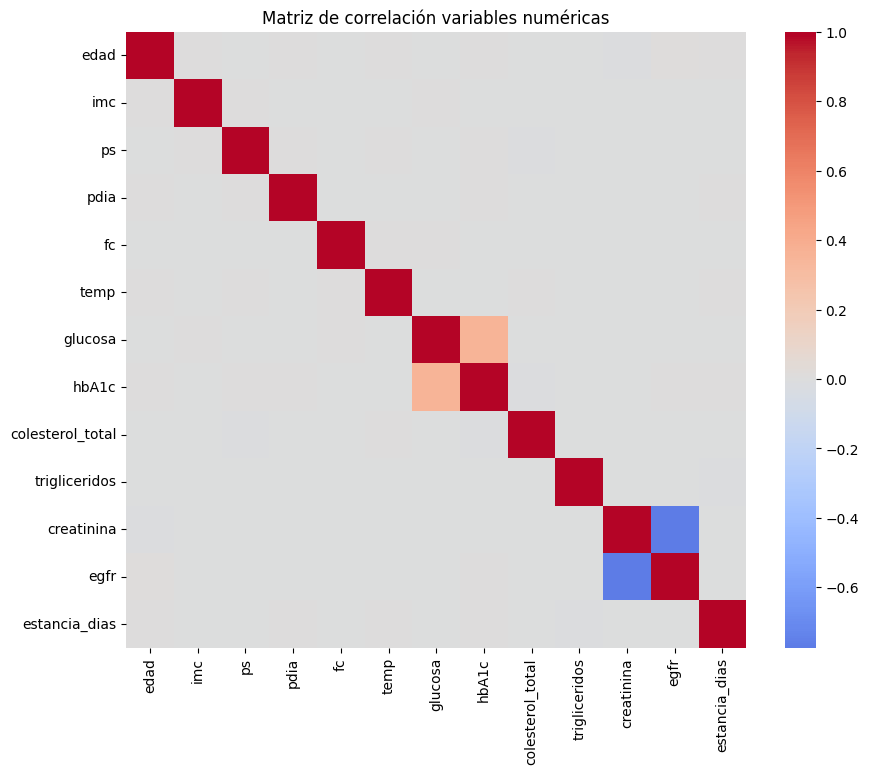

In [ ]:
#heatmap de correlaciones
corr = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación variables numéricas')
plt.show()

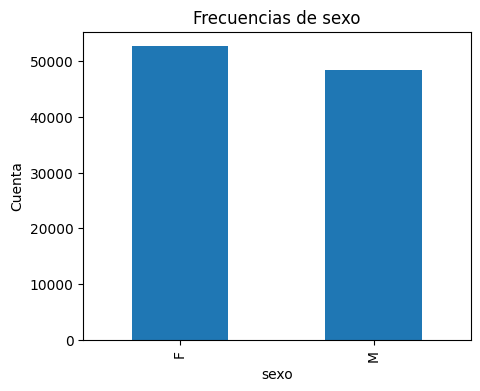

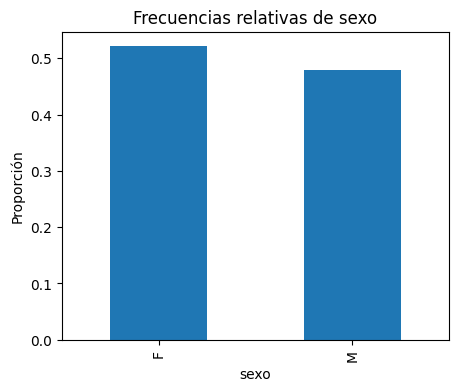

<Figure size 600x400 with 0 Axes>

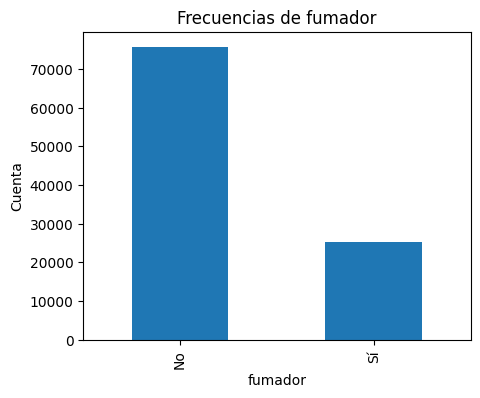

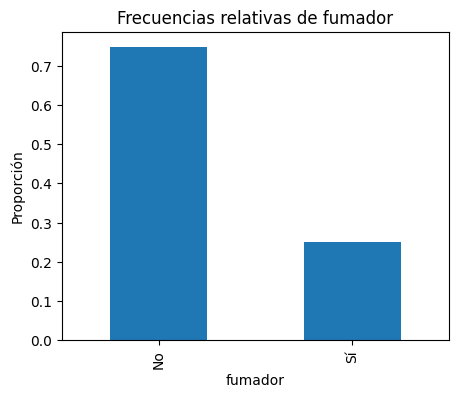

<Figure size 600x400 with 0 Axes>

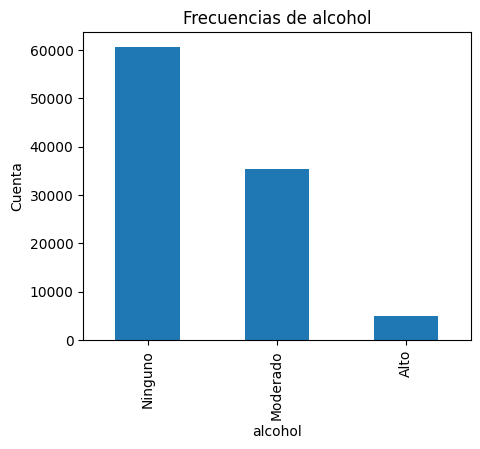

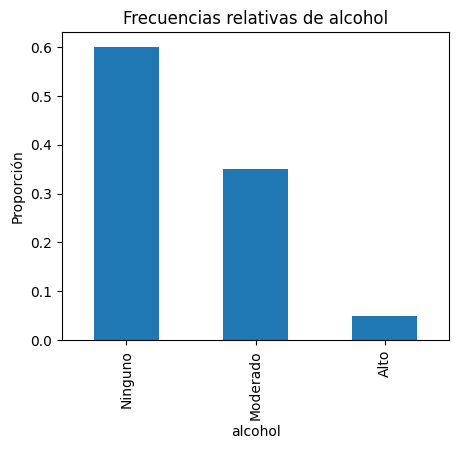

<Figure size 600x400 with 0 Axes>

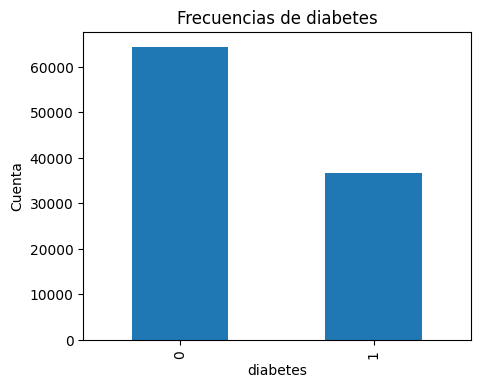

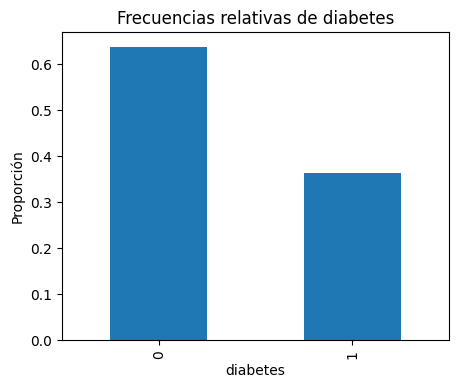

<Figure size 600x400 with 0 Axes>

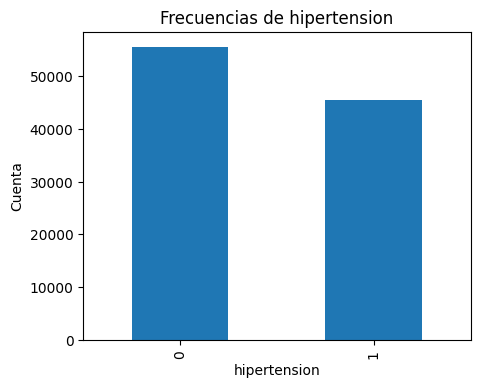

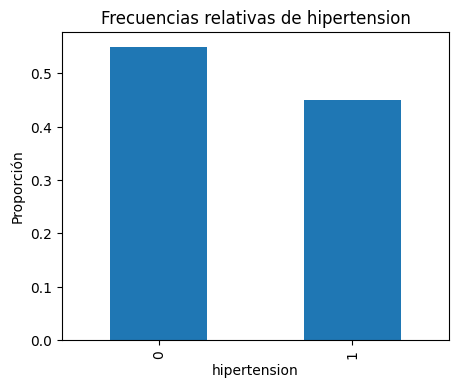

<Figure size 600x400 with 0 Axes>

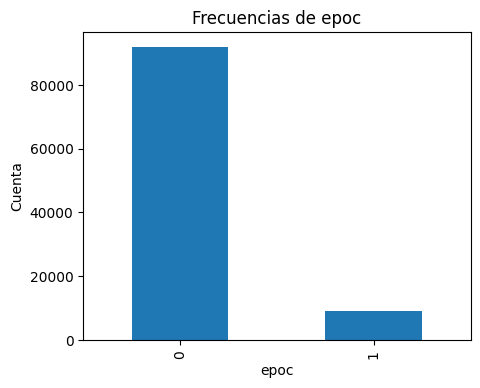

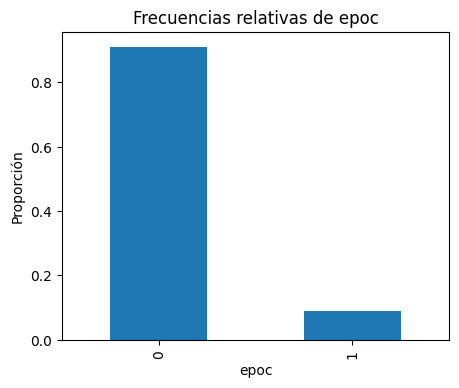

<Figure size 600x400 with 0 Axes>

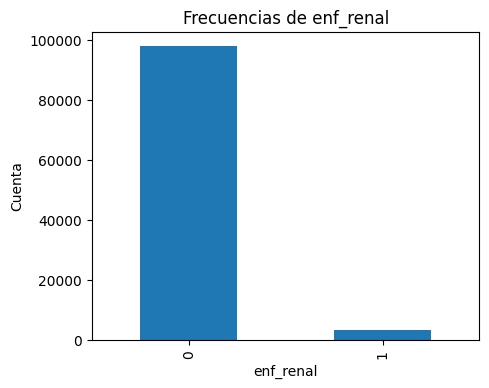

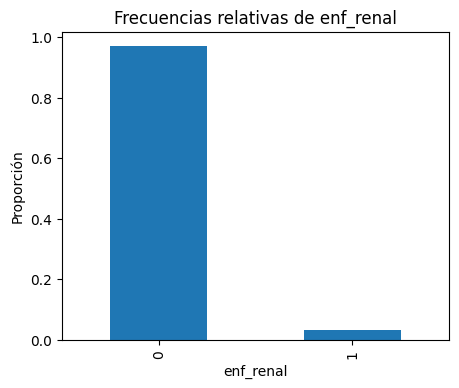

<Figure size 600x400 with 0 Axes>

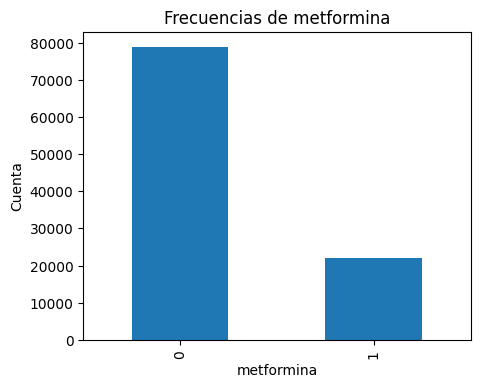

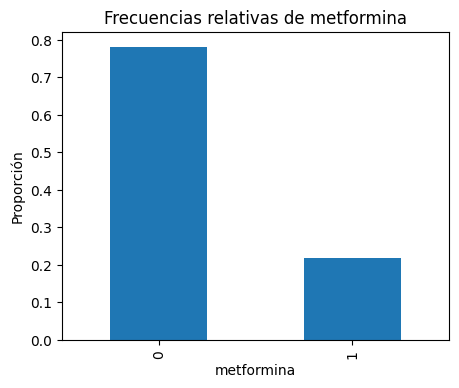

<Figure size 600x400 with 0 Axes>

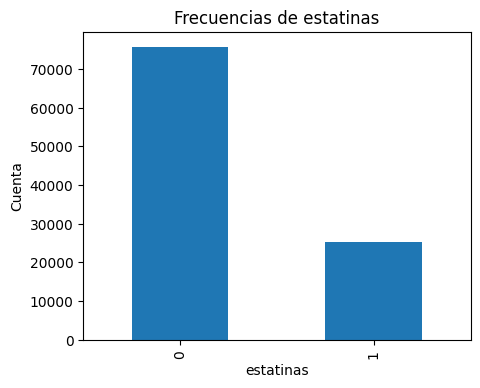

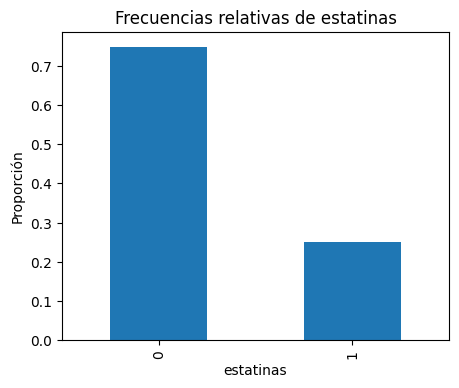

<Figure size 600x400 with 0 Axes>

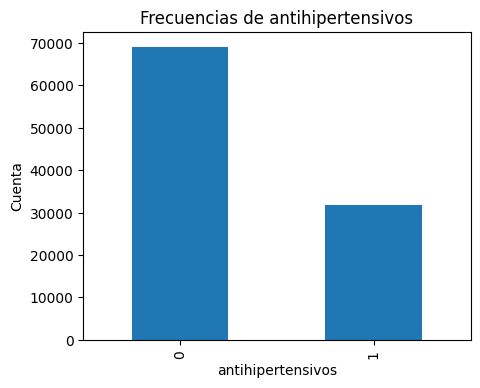

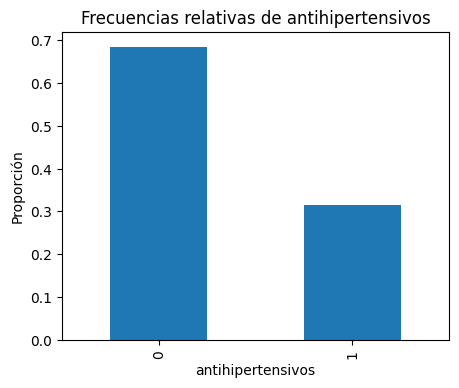

<Figure size 600x400 with 0 Axes>

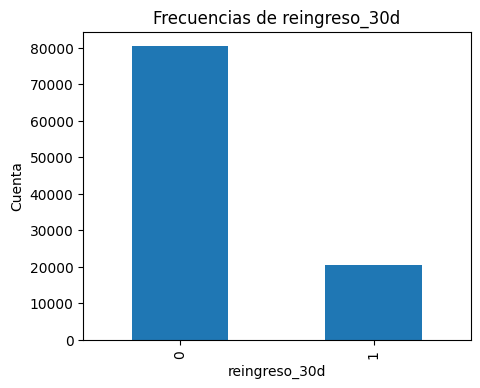

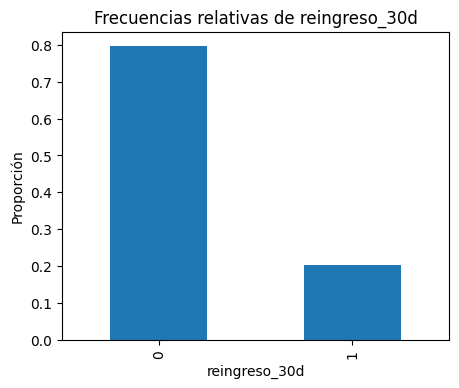

<Figure size 600x400 with 0 Axes>

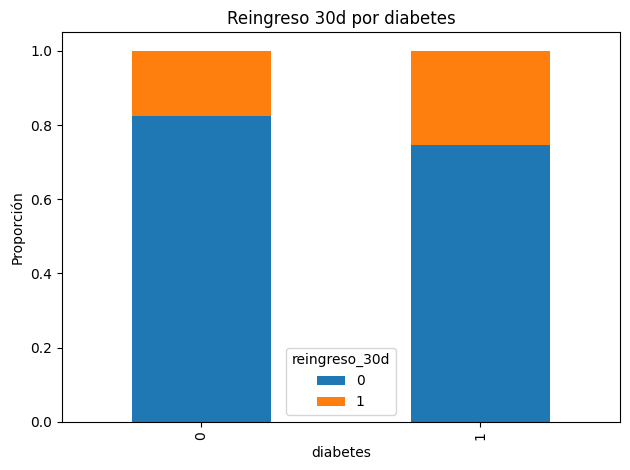

In [ ]:
#barras para categorías
cat_cols = ['sexo', 'fumador', 'alcohol', 'diabetes',
            'hipertension', 'epoc', 'enf_renal',
            'metformina', 'estatinas', 'antihipertensivos', 'reingreso_30d']

for col in cat_cols:
    plt.figure(figsize=(5, 4))
    df[col].value_counts(normalize=False).plot(kind='bar')
    plt.title(f'Frecuencias de {col}')
    plt.ylabel('Cuenta')
    plt.show()

    plt.figure(figsize=(5, 4))
    df[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(f'Frecuencias relativas de {col}')
    plt.ylabel('Proporción')
    plt.show()


    plt.figure(figsize=(6, 4))
tab = pd.crosstab(df['diabetes'], df['reingreso_30d'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.title('Reingreso 30d por diabetes')
plt.ylabel('Proporción')
plt.legend(title='reingreso_30d')
plt.tight_layout()
plt.show()

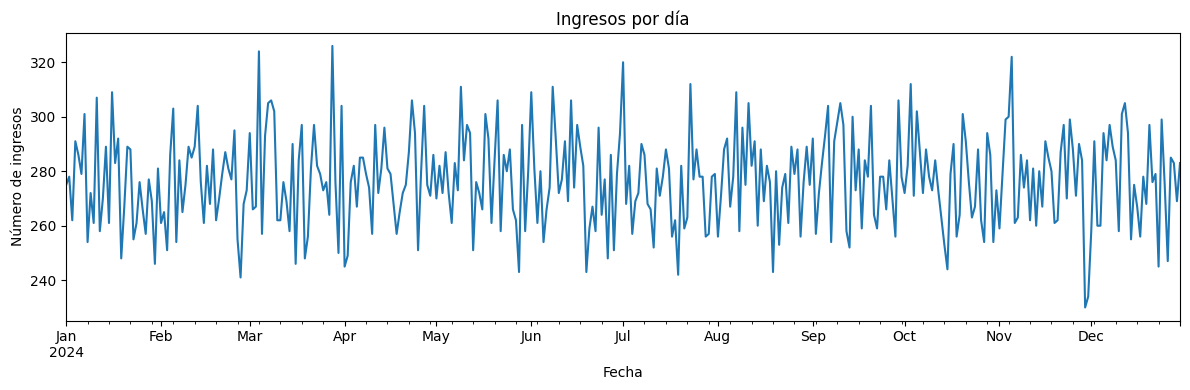

In [ ]:
#serie temporal fecha-ingreso
df['fecha_ingreso'] = pd.to_datetime(df['fecha_ingreso'])

fechas = df.groupby('fecha_ingreso').size()

plt.figure(figsize=(12, 4))
fechas.plot(kind='line')
plt.title('Ingresos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de ingresos')
plt.tight_layout()
plt.show()

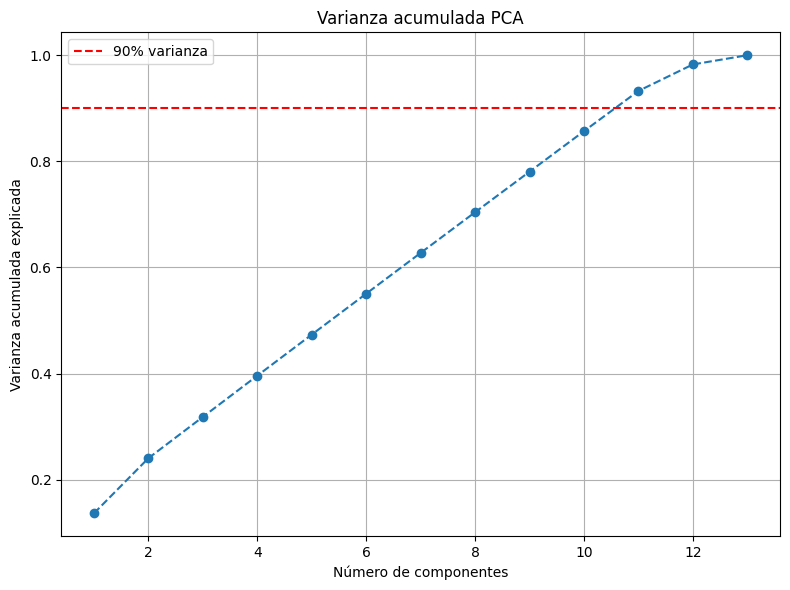

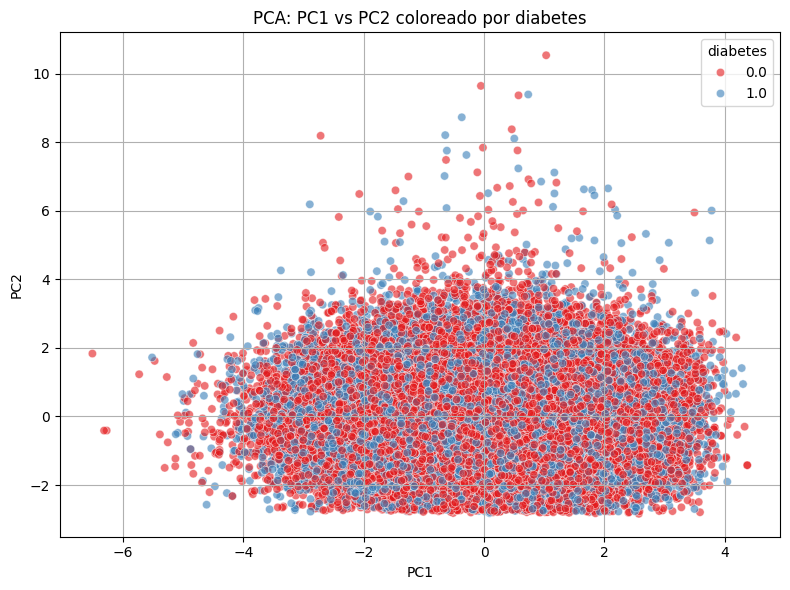

In [ ]:
#PCA varianza acumulada y PC1 vs PC2
# Usar mismas numéricas, eliminando filas con NaN
X = df_numeric.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca_result = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Varianza acumulada
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza acumulada PCA')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# PC1 vs PC2, coloreado por diabetes (ajusta variable si quieres otra)
pcadf = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
# Alineamos índices por haber hecho dropna en X
diab = df.loc[X.index, 'diabetes']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcadf['PC1'], y=pcadf['PC2'], hue=diab, alpha=0.6, palette='Set1')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2 coloreado por diabetes')
plt.legend(title='diabetes')
plt.grid(True)
plt.tight_layout()
plt.show()

Método de carga: Se ha usado carga en DataFrame de pandas porque permite importar de forma eficiente todas las filas y columnas, conservando tipos de datos y facilitando el análisis estadístico y gráfico posterior.
​

Inspección de entradas, columnas y tipos: Se revisan número de filas, columnas y tipos para comprobar que el dataset se ha importado correctamente, que el tamaño muestral es adecuado y para decidir qué variables son tratables como numéricas o categóricas en los análisis.
​

Qué aporta cada estadístico: Media y mediana describen el valor central, los cuartiles y el rango intercuartílico la dispersión central, mínimo y máximo posibles outliers, y la desviación estándar la variabilidad global de cada variable.
​

Elección de gráficos y tipo de distribución:

Histogramas (y densidad) se usan para ver la forma de la distribución (normal, asimétrica, colas) de las variables numéricas.
​

Boxplots se usan para identificar valores atípicos y comparar la dispersión entre variables una vez normalizadas.
​

El tipo de distribución se determina observando histogramas y boxplots: simetría y campana sugieren normalidad; colas largas o desplazamiento de la mediana indican asimetría.

Detección de datos problemáticos

In [ ]:
# trabajar solo con X
df = X.copy()

# 1) valores nulos
df.isna().sum()

# 2) duplicados
df.duplicated().sum()

np.int64(901)

Tres estrategias de tratamiento

In [ ]:
# 1) Eliminación completa de filas duplicadas (si existieran)
df = df.drop_duplicates()

# 2) Eliminación selectiva de filas con muchos nulos
umbral_nulos = 3  # por ejemplo, si hubiera >3 nulos en una fila
df = df[df.isna().sum(axis=1) <= umbral_nulos]

# 3) Imputación:
#   - numéricas: mediana
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

#   - categóricas: moda
for col in df.select_dtypes(exclude='number').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Detección y tratamiento de outliers

In [ ]:
df = X.copy()   # tu DataFrame original

numeric_cols = df.select_dtypes(include='number').columns

df_sin_outliers = df.copy()

for col in numeric_cols:
    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_sin_outliers = df_sin_outliers[
        (df_sin_outliers[col] >= lower) & (df_sin_outliers[col] <= upper)
    ]

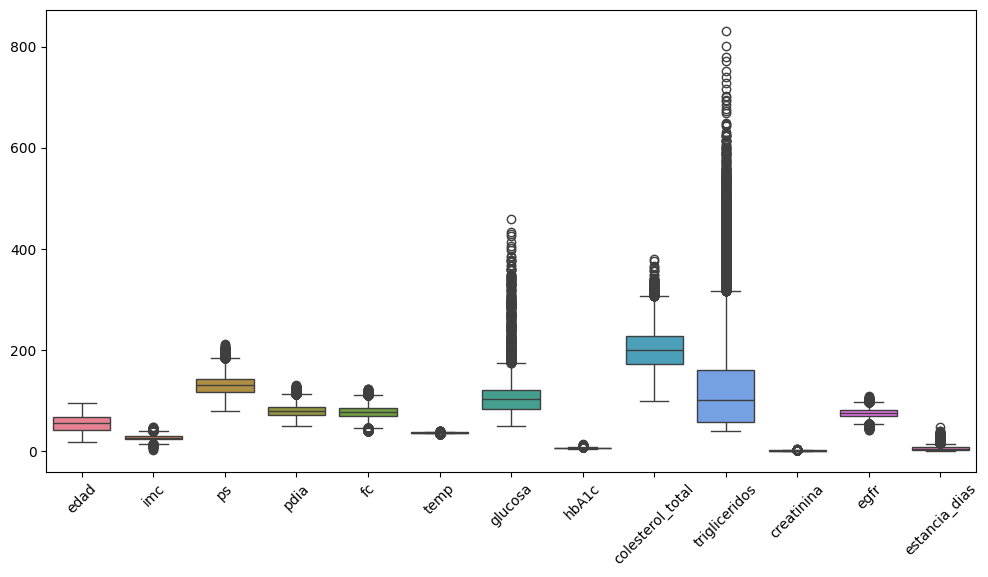

566

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include='number').columns

# Visualmente
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

# Regla IQR para una variable (ejemplo: 'gammagt')
col = 'glucosa'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]
len(outliers)

Filas originales: 89529
Filas tras eliminar outliers: 79222


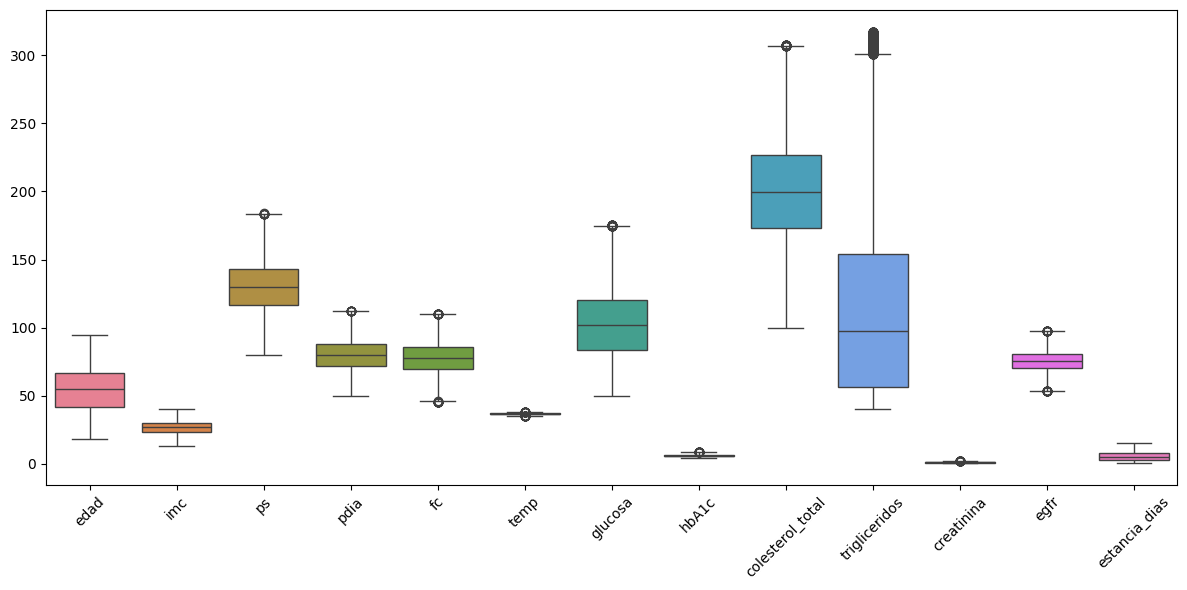

In [ ]:
df = X.copy()  # tu DataFrame original

numeric_cols = df.select_dtypes(include='number').columns

df_sin_outliers = df.copy()

for col in numeric_cols:
    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_sin_outliers = df_sin_outliers[
        (df_sin_outliers[col] >= lower) & (df_sin_outliers[col] <= upper)
    ]

print("Filas originales:", len(df))
print("Filas tras eliminar outliers:", len(df_sin_outliers))

import matplotlib.pyplot as plt
import seaborn as sns

# columnas numéricas del dataset ya limpiado
numeric_cols = df_sin_outliers.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df_sin_outliers[numeric_cols])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Por qué se identifican nulos, duplicados y outliers así
Se usan df.isna().sum() y df.duplicated().sum() porque permiten revisar todas las columnas a la vez con muy poco código y dan un recuento objetivo de valores ausentes y filas repetidas, algo necesario antes de aplicar cualquier modelo.
​

Los boxplots se utilizan porque muestran simultáneamente dispersión y valores extremos; son más informativos que mirar solo estadísticos numéricos y permiten decidir si hay outliers que puedan distorsionar la media o los modelos.
​

Justificación de las 3 estrategias
Eliminar duplicados

Si una fila está duplicada, no aporta nueva información, solo sobrerrepresenta ese caso en los cálculos de medias, proporciones y en los modelos; por eso se eliminan con drop_duplicates().
​

Eliminar filas con muchos nulos

Filas con demasiados valores perdidos obligan a imputar casi todo, lo que introduce mucha incertidumbre artificial.

Poner un umbral de nulos por fila y eliminar las que lo superan garantiza que solo se imputa donde aún hay información suficiente del paciente.
​

Imputar el resto de nulos con mediana/moda

La mediana es robusta a outliers y asimetrías, por lo que no se ve arrastrada por valores extremos, algo importante en variables como glucosa o triglicéridos.

La moda en categóricas mantiene la categoría más frecuente sin inventar valores nuevos, conservando la estructura de clases original.
​

Por qué ese criterio de outliers y por qué eliminarlos
Se usa la regla del 1,5·IQR porque es un criterio estándar, no depende de suponer normalidad y se adapta a la escala de cada variable; así se puede aplicar de forma uniforme a todas las numéricas.
​

Eliminar las observaciones fuera de
[
Q
1
−
1,5
⋅
I
Q
R
,

Q
3
+
1,5
⋅
I
Q
R
]
[Q1−1,5⋅IQR,Q3+1,5⋅IQR] reduce la influencia de valores extremadamente altos o bajos, que pueden deberse a errores de medida o registros atípicos y afectar mucho a modelos sensibles a la escala (como regresión o PCA).
​

Aplicar el mismo filtro IQR a todas las variables numéricas garantiza que la limpieza sea coherente y reproducible, y deja un conjunto de datos más estable para el análisis posterior.

parte 3 - correlación

Encontrar variables con correlación + o -

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print(df.columns)

Index(['edad', 'imc', 'ps', 'pdia', 'fc', 'temp', 'glucosa', 'hbA1c',
       'colesterol_total', 'trigliceridos', 'creatinina', 'egfr',
       'estancia_dias'],
      dtype='object')


Seleccionar numéricas y calcular correlación de Pearson

> Añadir blockquote



In [ ]:
# Seleccionar solo columnas numéricas automáticamente
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print("Columnas numéricas:", numeric_cols)

# DataFrame solo con numéricas y sin NaN
df_numeric = df[numeric_cols].dropna()

# Matriz de correlaciones de Pearson
corr_pearson = df_numeric.corr(method='pearson')
print("Matriz de correlaciones (Pearson):")
print(corr_pearson)

Columnas numéricas: ['edad', 'imc', 'ps', 'pdia', 'fc', 'temp', 'glucosa', 'hbA1c', 'colesterol_total', 'trigliceridos', 'creatinina', 'egfr', 'estancia_dias']
Matriz de correlaciones (Pearson):
                      edad       imc        ps      pdia        fc      temp  \
edad              1.000000  0.005571 -0.004881  0.001841 -0.001582  0.000811   
imc               0.005571  1.000000  0.002640  0.002295 -0.001053  0.001528   
ps               -0.004881  0.002640  1.000000  0.004622 -0.002095  0.004378   
pdia              0.001841  0.002295  0.004622  1.000000 -0.001332  0.002373   
fc               -0.001582 -0.001053 -0.002095 -0.001332  1.000000  0.004129   
temp              0.000811  0.001528  0.004378  0.002373  0.004129  1.000000   
glucosa           0.002876  0.005567  0.002513  0.001601  0.002258  0.000545   
hbA1c             0.004984  0.001970  0.004064  0.005767 -0.004192 -0.001926   
colesterol_total -0.002193  0.000268 -0.006338 -0.002720  0.000480  0.005775   
trigl

Scatter plots para correlaciones lineales

Correlación lineal ps–pdia: r = 0.005


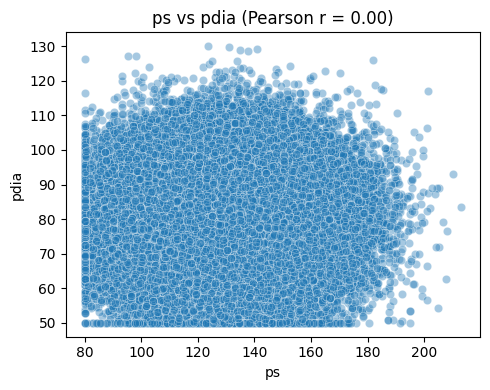

Correlación lineal glucosa–hbA1c: r = 0.350


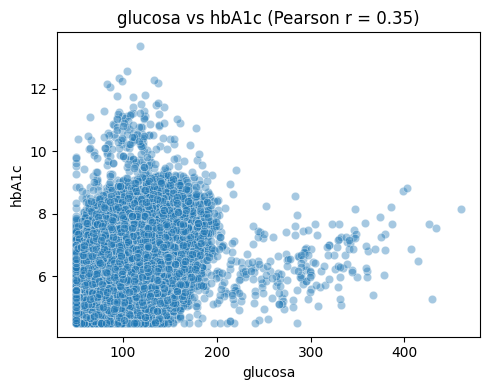

Correlación lineal edad–fc: r = -0.002


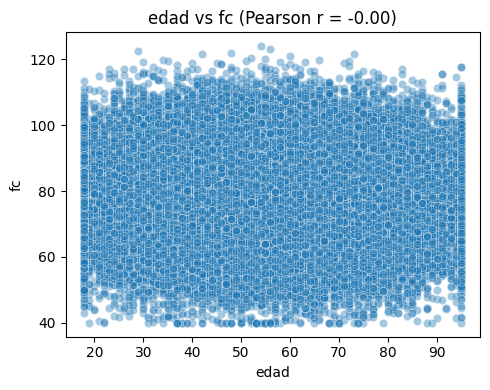

In [ ]:
# PARES que quieres representar (ajusta nombres según tu df.columns)
pairs_linear = [
    ('ps', 'pdia'),
    ('glucosa', 'hbA1c'),
    ('edad', 'fc'),
]

# Filtramos por si alguna columna no existe
pairs_linear = [(x, y) for (x, y) in pairs_linear
                if x in numeric_cols and y in numeric_cols]

for x, y in pairs_linear:
    r = corr_pearson.loc[x, y]
    print(f"Correlación lineal {x}–{y}: r = {r:.3f}")

    plt.figure(figsize=(5,4))
    sns.scatterplot(data=df_numeric, x=x, y=y, alpha=0.4)
    plt.title(f'{x} vs {y} (Pearson r = {r:.2f})')
    plt.tight_layout()
    plt.show()

Correlaciones no lineales Spearman

Matriz de correlaciones (Spearman):
                      edad       imc        ps      pdia        fc      temp  \
edad              1.000000  0.004211 -0.004567  0.001237 -0.000798  0.002644   
imc               0.004211  1.000000  0.001927  0.001176 -0.001730  0.001658   
ps               -0.004567  0.001927  1.000000  0.004776 -0.000970  0.003215   
pdia              0.001237  0.001176  0.004776  1.000000 -0.002626  0.002145   
fc               -0.000798 -0.001730 -0.000970 -0.002626  1.000000  0.003231   
temp              0.002644  0.001658  0.003215  0.002145  0.003231  1.000000   
glucosa           0.005725  0.005848  0.001451  0.002729  0.003000  0.000442   
hbA1c             0.005386  0.002838  0.004253  0.005857 -0.004136 -0.002812   
colesterol_total -0.003022  0.000393 -0.005831 -0.003655  0.000487  0.004580   
trigliceridos    -0.001631  0.001485  0.002136  0.000534 -0.000369 -0.000014   
creatinina       -0.005569 -0.003395  0.000495  0.000140  0.000883 -0.001903   
egfr

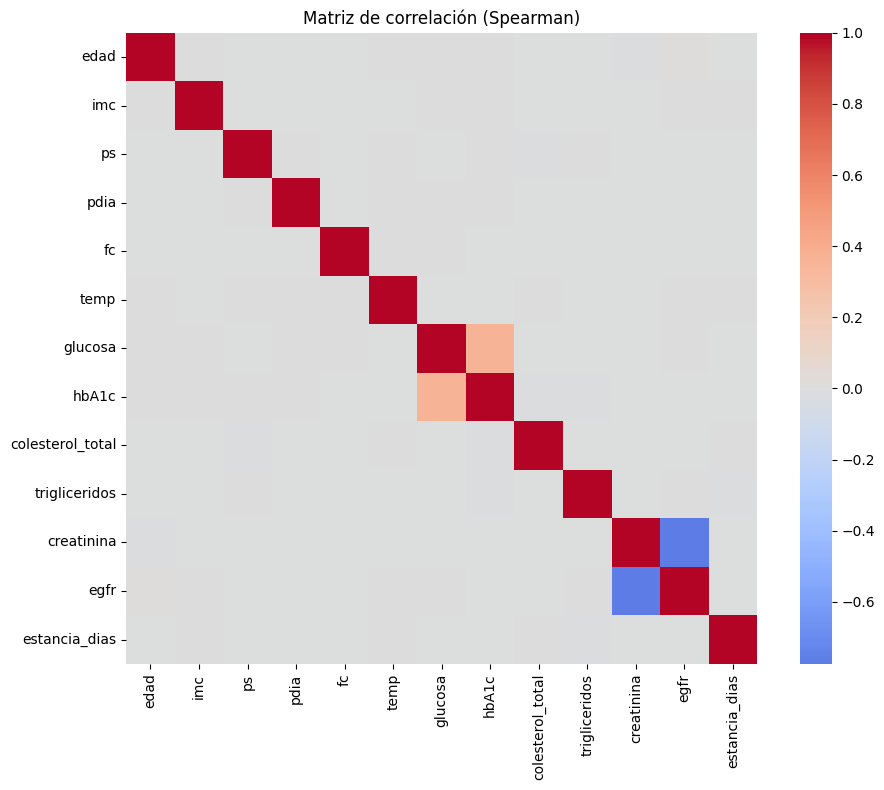

In [ ]:
# Matriz de correlaciones de Spearman
corr_spearman = df_numeric.corr(method='spearman')
print("Matriz de correlaciones (Spearman):")
print(corr_spearman)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación (Spearman)')
plt.tight_layout()
plt.show()

Pares “no lineales” - ejemplos de correlaciones no lineales

In [ ]:
pairs_nonlinear = [
    ('glucosa', 'hbA1c'),
    ('edad', 'estanciadias'),  # solo si 'estanciadias' existe
]

pairs_nonlinear = [(x, y) for (x, y) in pairs_nonlinear
                   if x in numeric_cols and y in numeric_cols]

for x, y in pairs_nonlinear:
    r_s = corr_spearman.loc[x, y]
    print(f"Correlación no lineal (Spearman) {x}–{y}: rho = {r_s:.3f}")

Correlación no lineal (Spearman) glucosa–hbA1c: rho = 0.360


Para identificar variables con correlación positiva o negativa entre las variables numéricas se ha utilizado el coeficiente de Pearson, ya que mide la fuerza y dirección de la relación lineal.
​

Para estudiar posibles correlaciones no lineales o monótonas, se ha empleado la correlación de Spearman y se ha representado la matriz de correlaciones en un mapa de calor.

Spark

Cargar el DataFrame

In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("PacientesSpark").getOrCreate()

import pandas as pd

df = pd.read_csv("/content/pacientes_biomedicina.csv")  # mismo archivo que usaste
sdf = spark.createDataFrame(df)

Mostrar esquema y 5 primeras filas

In [ ]:
sdf.printSchema()
sdf.show(5)

root
 |-- id: long (nullable = true)
 |-- fecha_ingreso: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- sexo: string (nullable = true)
 |-- fumador: string (nullable = true)
 |-- alcohol: string (nullable = true)
 |-- imc: double (nullable = true)
 |-- ps: double (nullable = true)
 |-- pdia: double (nullable = true)
 |-- fc: double (nullable = true)
 |-- temp: double (nullable = true)
 |-- glucosa: double (nullable = true)
 |-- hbA1c: double (nullable = true)
 |-- colesterol_total: double (nullable = true)
 |-- trigliceridos: double (nullable = true)
 |-- creatinina: double (nullable = true)
 |-- egfr: double (nullable = true)
 |-- diabetes: long (nullable = true)
 |-- hipertension: long (nullable = true)
 |-- epoc: long (nullable = true)
 |-- enf_renal: long (nullable = true)
 |-- metformina: long (nullable = true)
 |-- estatinas: long (nullable = true)
 |-- antihipertensivos: long (nullable = true)
 |-- estancia_dias: long (nullable = true)
 |-- reingreso_30d: long (

Tasa de reingreso por cada comorbilidad

In [ ]:
sdf.printSchema()

root
 |-- id: long (nullable = true)
 |-- fecha_ingreso: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- sexo: string (nullable = true)
 |-- fumador: string (nullable = true)
 |-- alcohol: string (nullable = true)
 |-- imc: double (nullable = true)
 |-- ps: double (nullable = true)
 |-- pdia: double (nullable = true)
 |-- fc: double (nullable = true)
 |-- temp: double (nullable = true)
 |-- glucosa: double (nullable = true)
 |-- hbA1c: double (nullable = true)
 |-- colesterol_total: double (nullable = true)
 |-- trigliceridos: double (nullable = true)
 |-- creatinina: double (nullable = true)
 |-- egfr: double (nullable = true)
 |-- diabetes: long (nullable = true)
 |-- hipertension: long (nullable = true)
 |-- epoc: long (nullable = true)
 |-- enf_renal: long (nullable = true)
 |-- metformina: long (nullable = true)
 |-- estatinas: long (nullable = true)
 |-- antihipertensivos: long (nullable = true)
 |-- estancia_dias: long (nullable = true)
 |-- reingreso_30d: long (

In [ ]:
#Asumiendo que reingreso_30d es 0/1, la tasa media es el porcentaje.

import pyspark.sql.functions as F

comorbs = ["diabetes", "hipertension", "epoc", "enf_renal"]

tasas = (
    sdf.groupBy(comorbs)
       .agg(F.mean("reingreso_30d").alias("tasa_reingreso"))
       .orderBy(comorbs)
)

tasas.show()

+--------+------------+----+---------+-------------------+
|diabetes|hipertension|epoc|enf_renal|     tasa_reingreso|
+--------+------------+----+---------+-------------------+
|       0|           0|   0|        0|0.14146154582894357|
|       0|           0|   0|        1| 0.2517412935323383|
|       0|           0|   1|        0|0.18925081433224755|
|       0|           0|   1|        1| 0.2857142857142857|
|       0|           1|   0|        0|0.20182694946485277|
|       0|           1|   0|        1|0.32066508313539194|
|       0|           1|   1|        0|0.23322683706070288|
|       0|           1|   1|        1| 0.3783783783783784|
|       1|           0|   0|        0|0.21548270608813405|
|       1|           0|   0|        1| 0.3031423290203327|
|       1|           0|   1|        0| 0.2859550561797753|
|       1|           0|   1|        1| 0.4716981132075472|
|       1|           1|   0|        0| 0.2796650881888683|
|       1|           1|   0|        1|0.4307036247334754

Cada fila corresponde a un patrón concreto de comorbilidades, definido por los valores 0/1 de diabetes, hipertension, epoc y enf_renal.
​

La columna tasa_reingreso es la proporción de pacientes reingresados en 30 días dentro de ese grupo, calculada como la media de reingreso_30d (porque vale 0 si no reingresa y 1 si reingresa).
​
​

Por ejemplo, una fila con diabetes=1, hipertension=1, epoc=1, enf_renal=0 y tasa_reingreso = 0.47 indica que aproximadamente el 47% de los pacientes con esas comorbilidades reingresan en los 30 días posteriores al alta.

La estancia media es de unos 6 días, con un rango amplio (1 a 47 días), lo que sugiere una mezcla de ingresos relativamente simples y otros complejos o complicados.
​

La tasa de reingreso a 30 días es cercana al 20%, un valor clínicamente relevante que justifica intentar modelos predictivos y estrategias de reducción.
​

La distribución de estancias y reingresos muestra suficiente variabilidad como para explorar asociaciones con comorbilidades y tratamientos.

Red Neuronal para predicción de glucosa

Importar librerías y el dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Cargar el dataset (asegúrate de subir dataset_AI.csv al Colab)
df_ai = pd.read_csv("/content/dataset_AI.csv")

# Vista rápida
print(df_ai.shape)
df_ai.head()

(300, 9)


,edad,imc,creatinina,colesterol,trigliceridos,fuma,alcohol,diabetes,glucosa
0,58,23.026270,0.997056,189.559607,68.352386,0,0,0,189.864090
1,71,28.692650,1.159281,205.956751,121.361579,0,0,0,212.400077
2,48,31.826420,0.943723,156.969051,190.024912,0,1,0,202.912503
3,34,28.494358,0.667061,217.430660,158.963730,0,0,0,177.478224
4,62,25.036577,0.998760,154.279543,176.642995,1,0,0,192.893858


Preparación de los datos para la red neuronal

In [ ]:
# 1. Definir variable objetivo (target) y predictores
# Asumimos que 'glucosa' está en el dataset y el resto de columnas numéricas se usan como X
target_col = "glucosa"

# Eliminar filas sin valor de glucosa
df_ai_clean = df_ai.dropna(subset=[target_col])

# Separar X e y
X = df_ai_clean.drop(columns=[target_col])
y = df_ai_clean[target_col]

# Opcional: si hay columnas categóricas, dummies
X = pd.get_dummies(X, drop_first=True)

# 2. Manejo de nulos en predictores (imputar con mediana)
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((240, 8), (60, 8))

Construir la red neuronal

In [ ]:
# Construcción del modelo
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="relu")  # salida con ReLU (según enunciado)
])

# Compilación: optimizador Adam
model.compile(
    optimizer="adam",
    loss="mse",          # para regresión
    metrics=["mae"]      # MAE durante el entrenamiento
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=400,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 37987.5273 - mae: 193.5890 - val_loss: 36623.8086 - val_mae: 189.7238
Epoch 2/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 37903.4141 - mae: 193.5220 - val_loss: 36390.5117 - val_mae: 189.1124
Epoch 3/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39191.3477 - mae: 196.7625 - val_loss: 36059.2656 - val_mae: 188.2450
Epoch 4/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37400.4336 - mae: 192.1043 - val_loss: 35575.4883 - val_mae: 186.9711
Epoch 5/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 36910.1602 - mae: 190.8826 - val_loss: 34874.7070 - val_mae: 185.1148
Epoch 6/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36079.9414 - mae: 188.8646 - val_loss: 33897.7656 - val_mae: 182.4973
Epoch 7/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 34522.2500 - mae: 184.7122 - val_loss: 32557.7012 - val_mae: 178.8552
Epoch 8/400
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33024.0977 - mae: 180.5639 - val_los